In [2]:
!pip install jupyter ipykernel numpy==1.26.4 pandas seaborn matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import sys
import os
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

root_path = Path(os.getcwd()).parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path / "src"))

from utils import TAG_INFO, THRESHOLDS

In [4]:
# ============================================================
# LOAD SESSIONS
# ============================================================

clean_sessions_path = "../data/processed/data_11-03_10-04/clean"

all_clean_files = glob.glob(os.path.join(clean_sessions_path, "*.csv"))
all_clean_files.sort(key=lambda x: int(os.path.basename(x).split('_')[2]))

last_two_files = all_clean_files[-2:]

dict_sessions = {}

for file in last_two_files:
    session_id              = int(os.path.basename(file).split('_')[2])
    dict_sessions[session_id] = pd.read_csv(file, index_col='timestamp', parse_dates=True)

print(f"{len(dict_sessions)} sessions loaded")
for session_id, df in dict_sessions.items():
    print(f"  Session {session_id}: {len(df)} rows — {df.index.min()} to {df.index.max()}")

# ============================================================
# OUTPUT DIRECTORIES
# ============================================================

output_dir_single   = "../data/augmented/single_faults"
output_dir_combined = "../data/augmented/combined_faults"
output_dir_fp       = "../data/augmented/false_positives"

os.makedirs(output_dir_single,   exist_ok=True)
os.makedirs(output_dir_combined, exist_ok=True)
os.makedirs(output_dir_fp,       exist_ok=True)

2 sessions loaded
  Session 16: 3367 rows — 2026-04-04 19:45:00 to 2026-04-07 03:51:00
  Session 17: 4415 rows — 2026-04-07 07:42:00 to 2026-04-10 09:16:00


In [5]:
""" Define thresholds and severity target levels explicitly """

# ============================================================
# THRESHOLDS
# ============================================================

# TT-901 — Oil separator gas temperature
tt901_warning = THRESHOLDS["TT-901"]["warning"]   # 135°C
tt901_trip    = THRESHOLDS["TT-901"]["trip"]       # 140°C

# TT-902 — Discharge 1 temperature
tt902_warning = THRESHOLDS["TT-902"]["warning"]   # 105°C
tt902_trip    = THRESHOLDS["TT-902"]["trip"]       # 110°C

# TT-903 — Discharge 2 temperature
tt903_warning = THRESHOLDS["TT-903"]["warning"]   # 105°C
tt903_trip    = THRESHOLDS["TT-903"]["trip"]       # 110°C

# TT-904 — Oil temperature
tt904_warning = THRESHOLDS["TT-904"]["warning"]   # 90°C
tt904_trip    = THRESHOLDS["TT-904"]["trip"]       # 110°C

# PT-903 — Vacuum pressure in oil separator
pt903_warning = THRESHOLDS["PT-903"]["warning"]   # 0.4 bar
pt903_trip    = THRESHOLDS["PT-903"]["trip"]       # 0.5 bar

# ============================================================
# SEVERITY TARGET LEVELS
# ============================================================

# Small  — stays well below warning (25% of warning level)
tt901_small_target  = tt901_warning * 0.25    # 33.75°C delta target
tt902_small_target  = tt902_warning * 0.25    # 26.25°C delta target
tt903_small_target  = tt903_warning * 0.25    # 26.25°C delta target
tt904_small_target  = tt904_warning * 0.25    # 22.50°C delta target
pt903_small_target  = pt903_warning * 0.25    # 0.10 bar delta target

# Medium — reaches 55% of trip level
tt901_medium_target = tt901_trip * 0.55       # 77.00°C delta target
tt902_medium_target = tt902_trip * 0.55       # 60.50°C delta target
tt903_medium_target = tt903_trip * 0.55       # 60.50°C delta target
tt904_medium_target = tt904_trip * 0.55       # 60.50°C delta target
pt903_medium_target = pt903_trip * 0.55       # 0.275 bar delta target

# Severe — reaches trip level
tt901_severe_target = tt901_trip              # 140°C
tt902_severe_target = tt902_trip              # 110°C
tt903_severe_target = tt903_trip              # 110°C
tt904_severe_target = tt904_trip              # 110°C
pt903_severe_target = pt903_trip              # 0.5 bar

print("Thresholds and severity targets defined")
print(f"\nPT-903 — small: {pt903_small_target:.3f} bar | medium: {pt903_medium_target:.3f} bar | severe: {pt903_severe_target:.3f} bar")
print(f"TT-901 — small: {tt901_small_target:.2f}°C | medium: {tt901_medium_target:.2f}°C | severe: {tt901_severe_target:.2f}°C")
print(f"TT-904 — small: {tt904_small_target:.2f}°C | medium: {tt904_medium_target:.2f}°C | severe: {tt904_severe_target:.2f}°C")

Thresholds and severity targets defined

PT-903 — small: 0.100 bar | medium: 0.275 bar | severe: 0.500 bar
TT-901 — small: 33.75°C | medium: 77.00°C | severe: 140.00°C
TT-904 — small: 22.50°C | medium: 60.50°C | severe: 110.00°C


### F1 Fault

In [6]:
""" F1 Small — Clogged Exhaust Filters — Session 16 """

np.random.seed(42)

# ============================================================
# BASE SESSION
# ============================================================

df_session_16 = dict_sessions[16].copy()

# ============================================================
# FAULT PARAMETERS
# ============================================================

f1_small_main_sensor    = "PT-903"
f1_small_session_length = len(df_session_16)
f1_small_start_from     = 0.30
f1_small_length_hours   = 6
f1_small_smooth_window  = 20

f1_small_start_idx  = int(round(f1_small_session_length * f1_small_start_from))
f1_small_end_idx    = min(f1_small_start_idx + int(round(f1_small_length_hours * 60)), f1_small_session_length)
f1_small_total_l    = f1_small_end_idx - f1_small_start_idx

print(f"Session 16 length:       {f1_small_session_length} rows")
print(f"Fault start index:       {f1_small_start_idx}")
print(f"Fault end index:         {f1_small_end_idx}")
print(f"Fault window length:     {f1_small_total_l} rows")

# ============================================================
# BASELINE — computed on pre-fault window
# ============================================================

f1_small_baseline_mean  = df_session_16["PT-903"].iloc[:f1_small_start_idx].mean()
f1_small_baseline_std   = df_session_16["PT-903"].iloc[:f1_small_start_idx].std()

print(f"\nPT-903 baseline mean:    {f1_small_baseline_mean:.4f} bar")
print(f"PT-903 baseline std:     {f1_small_baseline_std:.4f} bar")

# ============================================================
# SEVERITY TARGET — small = 25% of warning level
# ============================================================

f1_small_amplitude = pt903_warning * 0.25     # 0.10 bar

print(f"PT-903 small amplitude:  {f1_small_amplitude:.4f} bar")

# ============================================================
# DELTA SHAPE — micro ramp (smoothstep)
# ============================================================

f1_small_t          = np.linspace(0, 1, f1_small_total_l)
f1_small_smoothstep = 3 * f1_small_t**2 - 2 * f1_small_t**3
f1_small_noise      = np.random.normal(0, f1_small_baseline_std * 0.08, f1_small_total_l)
f1_small_noise      = pd.Series(f1_small_noise).rolling(f1_small_smooth_window, center=True, min_periods=1).mean().values
f1_small_delta      = f1_small_amplitude * f1_small_smoothstep + f1_small_noise

# ============================================================
# CORRELATION — computed on full session
# ============================================================

f1_small_corr_threshold = 0.70
f1_small_corr           = df_session_16.corr(method="pearson", numeric_only=True)["PT-903"]
f1_small_corr_sensors   = f1_small_corr[abs(f1_small_corr) >= f1_small_corr_threshold].index.tolist()

print(f"\nCorrelated sensors (|r| >= {f1_small_corr_threshold}): {f1_small_corr_sensors}")

# ============================================================
# INJECT FAULT
# ============================================================

df_f1_small_s16 = df_session_16.copy()

f1_small_propagation_scale = 0.25

for sensor in f1_small_corr_sensors:
    if sensor in df_f1_small_s16.columns:
        scale = 1.0 if sensor == f1_small_main_sensor else f1_small_propagation_scale
        df_f1_small_s16.iloc[f1_small_start_idx:f1_small_end_idx, df_f1_small_s16.columns.get_loc(sensor)] += f1_small_delta * f1_small_corr[sensor] * scale

# ============================================================
# DECAY PHASE
# ============================================================

f1_small_decay_rate      = 1.2
f1_small_remaining       = f1_small_session_length - f1_small_end_idx
f1_small_decay           = f1_small_delta[-1] * np.exp(-f1_small_decay_rate * np.linspace(0, 1, f1_small_remaining))

for sensor in f1_small_corr_sensors:
    if sensor in df_f1_small_s16.columns:
        scale = 1.0 if sensor == f1_small_main_sensor else f1_small_propagation_scale
        df_f1_small_s16.iloc[f1_small_end_idx:, df_f1_small_s16.columns.get_loc(sensor)] += f1_small_decay * f1_small_corr[sensor] * scale

# ============================================================
# LABELS
# ============================================================

df_f1_small_s16["anomaly_level"]      = 0
df_f1_small_s16["is_injected_anomaly"] = 0
df_f1_small_s16["anomaly_type"]        = "normal"

df_f1_small_s16.iloc[f1_small_start_idx:f1_small_end_idx, df_f1_small_s16.columns.get_loc("anomaly_level")]       = 1
df_f1_small_s16.iloc[f1_small_start_idx:f1_small_end_idx, df_f1_small_s16.columns.get_loc("is_injected_anomaly")] = 1
df_f1_small_s16.iloc[f1_small_start_idx:f1_small_end_idx, df_f1_small_s16.columns.get_loc("anomaly_type")]        = "clogged_filters"

# ============================================================
# SAVE
# ============================================================

df_f1_small_s16.to_csv(f"{output_dir_single}/session_16_F1_small.csv")

print(f"\nSession 16 F1 small saved")
print(f"Anomaly rows:  {df_f1_small_s16['is_injected_anomaly'].sum()}")
print(f"Normal rows:   {(df_f1_small_s16['is_injected_anomaly'] == 0).sum()}")

Session 16 length:       3367 rows
Fault start index:       1010
Fault end index:         1370
Fault window length:     360 rows

PT-903 baseline mean:    0.0744 bar
PT-903 baseline std:     0.0697 bar
PT-903 small amplitude:  0.1000 bar

Correlated sensors (|r| >= 0.7): ['FT-901', 'PT-901', 'PT-902', 'PT-903', 'VSD-901_CORRENT', 'VSD-901_POWER']

Session 16 F1 small saved
Anomaly rows:  360
Normal rows:   3007


#### Small

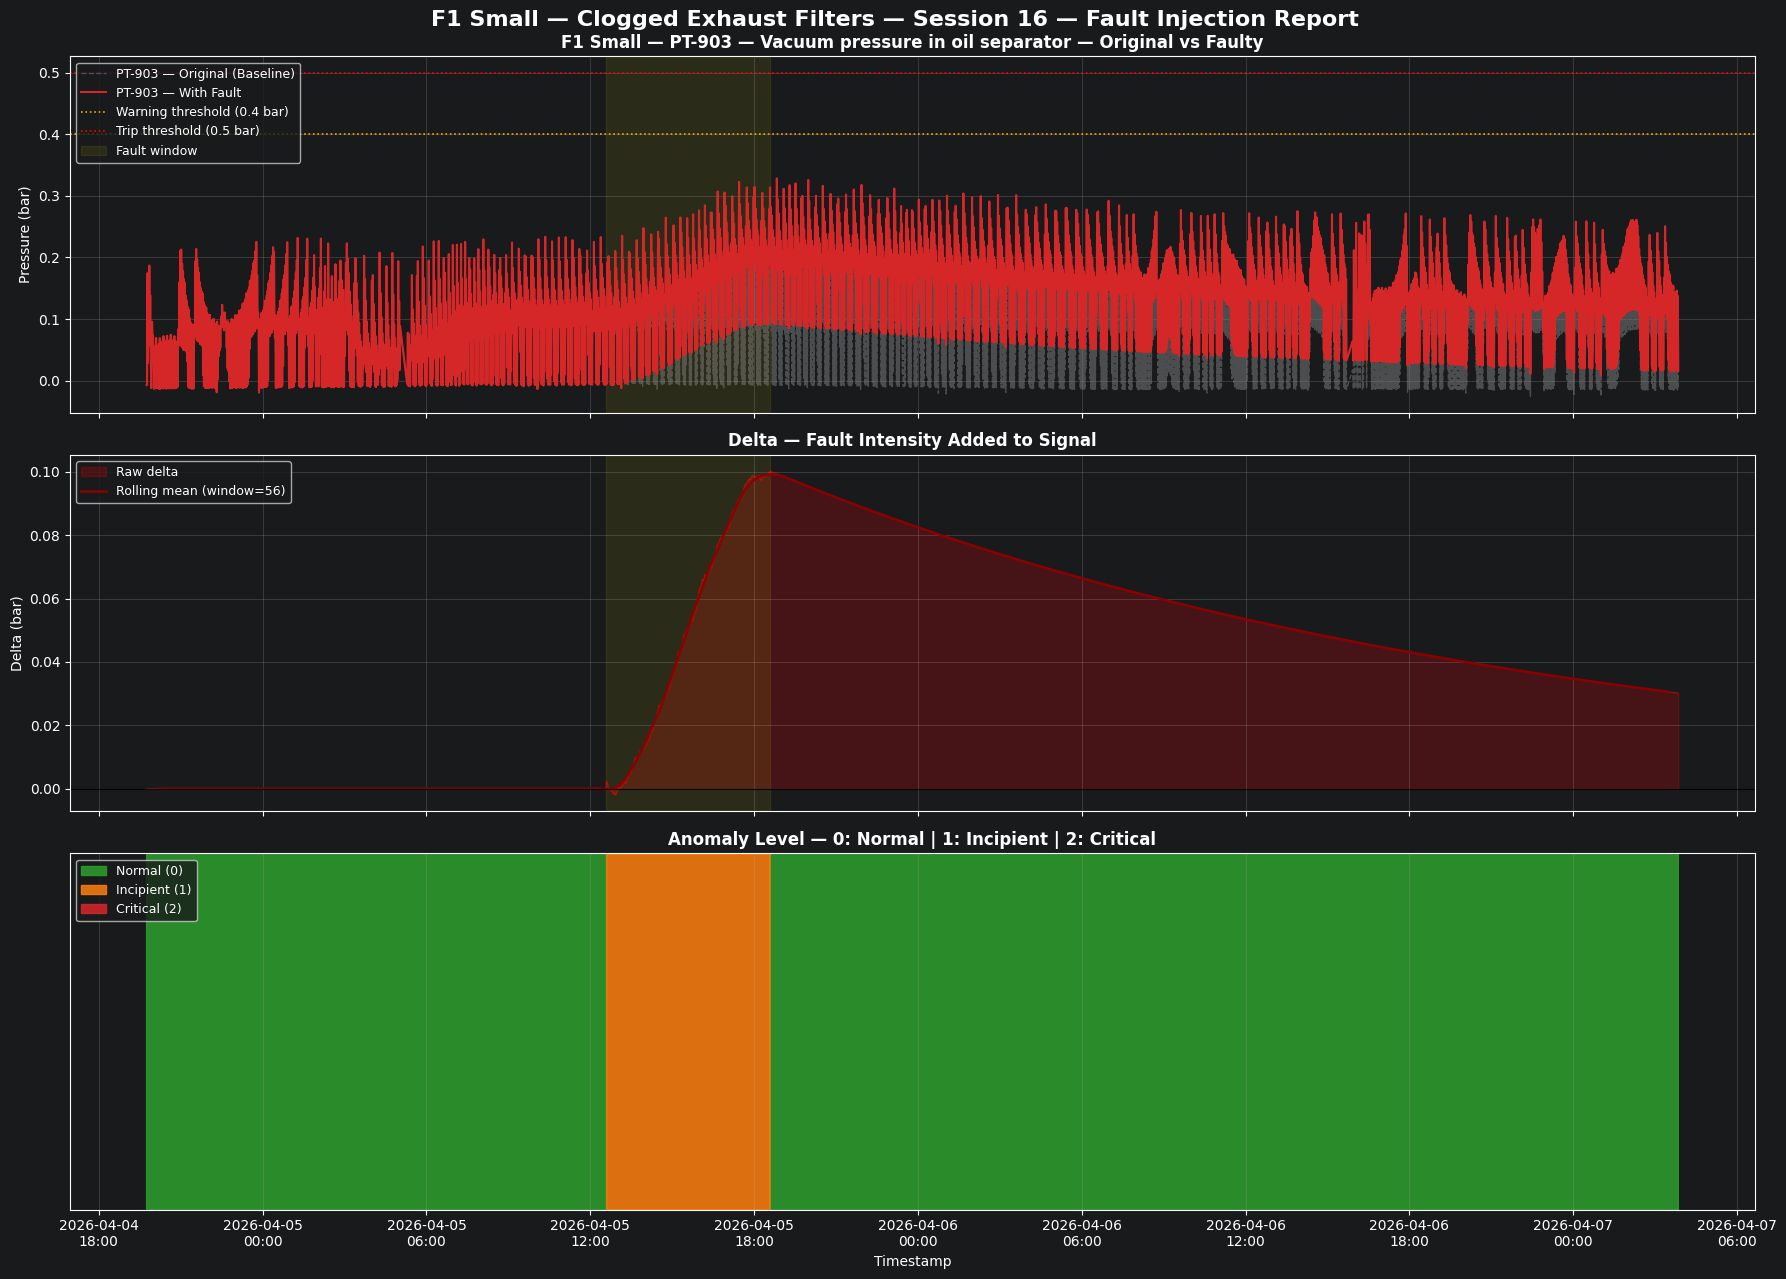

In [7]:
""" F1 Small — Fault Profile Verification Plot — Session 16 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty PT-903
# ============================================================

f1_small_fault_start_timestamp = df_f1_small_s16.index[f1_small_start_idx]
f1_small_fault_end_timestamp   = df_f1_small_s16.index[f1_small_end_idx - 1]

ax1.plot(
    df_session_16.index,
    df_session_16["PT-903"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="PT-903 — Original (Baseline)"
)

ax1.plot(
    df_f1_small_s16.index,
    df_f1_small_s16["PT-903"],
    color="#d62728",
    linewidth=1.5,
    label="PT-903 — With Fault"
)

ax1.axhline(
    y=pt903_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({pt903_warning} bar)"
)

ax1.axhline(
    y=pt903_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({pt903_trip} bar)"
)

ax1.axvspan(
    f1_small_fault_start_timestamp,
    f1_small_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F1 Small — PT-903 — Vacuum pressure in oil separator — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Pressure (bar)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f1_small_delta_full  = df_f1_small_s16["PT-903"] - df_session_16["PT-903"]
f1_small_roll_window = max(10, len(f1_small_delta_full) // 60)
f1_small_delta_rolling_mean = f1_small_delta_full.rolling(f1_small_roll_window, center=True).mean()

ax2.fill_between(
    df_f1_small_s16.index,
    0,
    f1_small_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    df_f1_small_s16.index,
    f1_small_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    df_f1_small_s16.index,
    f1_small_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f1_small_roll_window})"
)

ax2.axhline(
    y=0,
    color="black",
    linewidth=0.8
)

ax2.axvspan(
    f1_small_fault_start_timestamp,
    f1_small_fault_end_timestamp,
    color="yellow",
    alpha=0.08
)

ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (bar)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f1_small_normal_mask    = df_f1_small_s16["anomaly_level"] == 0
f1_small_incipient_mask = df_f1_small_s16["anomaly_level"] == 1
f1_small_critical_mask  = df_f1_small_s16["anomaly_level"] == 2

ax3.fill_between(
    df_f1_small_s16.index,
    0, 1,
    where=f1_small_normal_mask,
    color="#2ca02c",
    step="mid",
    alpha=0.85,
    label="Normal (0)"
)

ax3.fill_between(
    df_f1_small_s16.index,
    0, 1,
    where=f1_small_incipient_mask,
    color="#ff7f0e",
    step="mid",
    alpha=0.85,
    label="Incipient (1)"
)

ax3.fill_between(
    df_f1_small_s16.index,
    0, 1,
    where=f1_small_critical_mask,
    color="#d62728",
    step="mid",
    alpha=0.85,
    label="Critical (2)"
)

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F1 Small — Clogged Exhaust Filters — Session 16 — Fault Injection Report", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

#### Medium

In [8]:
""" F1 Medium — Clogged Exhaust Filters — Session 16 """

np.random.seed(42)

# ============================================================
# BASE SESSION
# ============================================================

df_session_16 = dict_sessions[16].copy()

# ============================================================
# FAULT PARAMETERS
# ============================================================

f1_medium_main_sensor    = "PT-903"
f1_medium_session_length = len(df_session_16)
f1_medium_start_from     = 0.45
f1_medium_length_hours   = 10
f1_medium_smooth_window  = 10

f1_medium_start_idx = int(round(f1_medium_session_length * f1_medium_start_from))
f1_medium_end_idx   = min(f1_medium_start_idx + int(round(f1_medium_length_hours * 60)), f1_medium_session_length)
f1_medium_total_l   = f1_medium_end_idx - f1_medium_start_idx

print(f"Session 16 length:       {f1_medium_session_length} rows")
print(f"Fault start index:       {f1_medium_start_idx}")
print(f"Fault end index:         {f1_medium_end_idx}")
print(f"Fault window length:     {f1_medium_total_l} rows")

# ============================================================
# BASELINE — computed on pre-fault window
# ============================================================

f1_medium_baseline_mean = df_session_16["PT-903"].iloc[:f1_medium_start_idx].mean()
f1_medium_baseline_std  = df_session_16["PT-903"].iloc[:f1_medium_start_idx].std()

print(f"\nPT-903 baseline mean:    {f1_medium_baseline_mean:.4f} bar")
print(f"PT-903 baseline std:     {f1_medium_baseline_std:.4f} bar")

# ============================================================
# SEVERITY TARGET — medium = trip * 0.55
# ============================================================

f1_medium_target    = pt903_trip * 0.55
f1_medium_delta_mag = f1_medium_target - f1_medium_baseline_mean

print(f"PT-903 medium target:    {f1_medium_target:.4f} bar")
print(f"PT-903 delta magnitude:  {f1_medium_delta_mag:.4f} bar")

# ============================================================
# DELTA SHAPE — ramp with noise
# ============================================================

f1_medium_trend       = np.linspace(0, f1_medium_delta_mag, f1_medium_total_l)
f1_medium_noise_scale = np.linspace(f1_medium_baseline_std * 0.1, f1_medium_baseline_std * 0.5, f1_medium_total_l)
f1_medium_noise       = np.random.normal(0, f1_medium_noise_scale, f1_medium_total_l)
f1_medium_ramp        = f1_medium_trend + f1_medium_noise
f1_medium_delta       = pd.Series(f1_medium_ramp).rolling(f1_medium_smooth_window, center=True, min_periods=1).mean().values

# ============================================================
# CORRELATION — computed on full session
# ============================================================

f1_medium_corr_threshold = 0.70
f1_medium_corr           = df_session_16.corr(method="pearson", numeric_only=True)["PT-903"]
f1_medium_corr_sensors   = f1_medium_corr[abs(f1_medium_corr) >= f1_medium_corr_threshold].index.tolist()

print(f"\nCorrelated sensors (|r| >= {f1_medium_corr_threshold}): {f1_medium_corr_sensors}")

# ============================================================
# INJECT FAULT
# ============================================================

df_f1_medium_s16 = df_session_16.copy()

f1_medium_propagation_scale = 0.25

for sensor in f1_medium_corr_sensors:
    if sensor in df_f1_medium_s16.columns:
        scale = 1.0 if sensor == f1_medium_main_sensor else f1_medium_propagation_scale
        df_f1_medium_s16.iloc[f1_medium_start_idx:f1_medium_end_idx, df_f1_medium_s16.columns.get_loc(sensor)] += f1_medium_delta * f1_medium_corr[sensor] * scale

# ============================================================
# DECAY PHASE
# ============================================================

f1_medium_decay_rate  = 0.3
f1_medium_remaining   = f1_medium_session_length - f1_medium_end_idx
f1_medium_decay       = f1_medium_delta[-1] * np.exp(-f1_medium_decay_rate * np.linspace(0, 1, f1_medium_remaining))

for sensor in f1_medium_corr_sensors:
    if sensor in df_f1_medium_s16.columns:
        scale = 1.0 if sensor == f1_medium_main_sensor else f1_medium_propagation_scale
        df_f1_medium_s16.iloc[f1_medium_end_idx:, df_f1_medium_s16.columns.get_loc(sensor)] += f1_medium_decay * f1_medium_corr[sensor] * scale

# ============================================================
# LABELS
# ============================================================

df_f1_medium_s16["anomaly_level"]       = 0
df_f1_medium_s16["is_injected_anomaly"] = 0
df_f1_medium_s16["anomaly_type"]        = "normal"

f1_medium_injected_values = df_f1_medium_s16["PT-903"].iloc[f1_medium_start_idx:]

f1_medium_labels = np.where(
    f1_medium_injected_values >= pt903_trip,    2,
    np.where(
    f1_medium_injected_values >= pt903_warning, 1,
                                                0)
)

df_f1_medium_s16.iloc[f1_medium_start_idx:, df_f1_medium_s16.columns.get_loc("anomaly_level")]       = f1_medium_labels
df_f1_medium_s16.iloc[f1_medium_start_idx:, df_f1_medium_s16.columns.get_loc("is_injected_anomaly")] = 1
df_f1_medium_s16.iloc[f1_medium_start_idx:, df_f1_medium_s16.columns.get_loc("anomaly_type")]        = "clogged_filters"

# ============================================================
# SAVE
# ============================================================

df_f1_medium_s16.to_csv(f"{output_dir_single}/session_16_F1_medium.csv")

print(f"\nSession 16 F1 medium saved")
print(f"Anomaly rows:  {df_f1_medium_s16['is_injected_anomaly'].sum()}")
print(f"Normal rows:   {(df_f1_medium_s16['is_injected_anomaly'] == 0).sum()}")
print(f"Level 1 rows:  {(df_f1_medium_s16['anomaly_level'] == 1).sum()}")
print(f"Level 2 rows:  {(df_f1_medium_s16['anomaly_level'] == 2).sum()}")

Session 16 length:       3367 rows
Fault start index:       1515
Fault end index:         2115
Fault window length:     600 rows

PT-903 baseline mean:    0.0800 bar
PT-903 baseline std:     0.0713 bar
PT-903 medium target:    0.2750 bar
PT-903 delta magnitude:  0.1950 bar

Correlated sensors (|r| >= 0.7): ['FT-901', 'PT-901', 'PT-902', 'PT-903', 'VSD-901_CORRENT', 'VSD-901_POWER']

Session 16 F1 medium saved
Anomaly rows:  1852
Normal rows:   1515
Level 1 rows:  4
Level 2 rows:  0


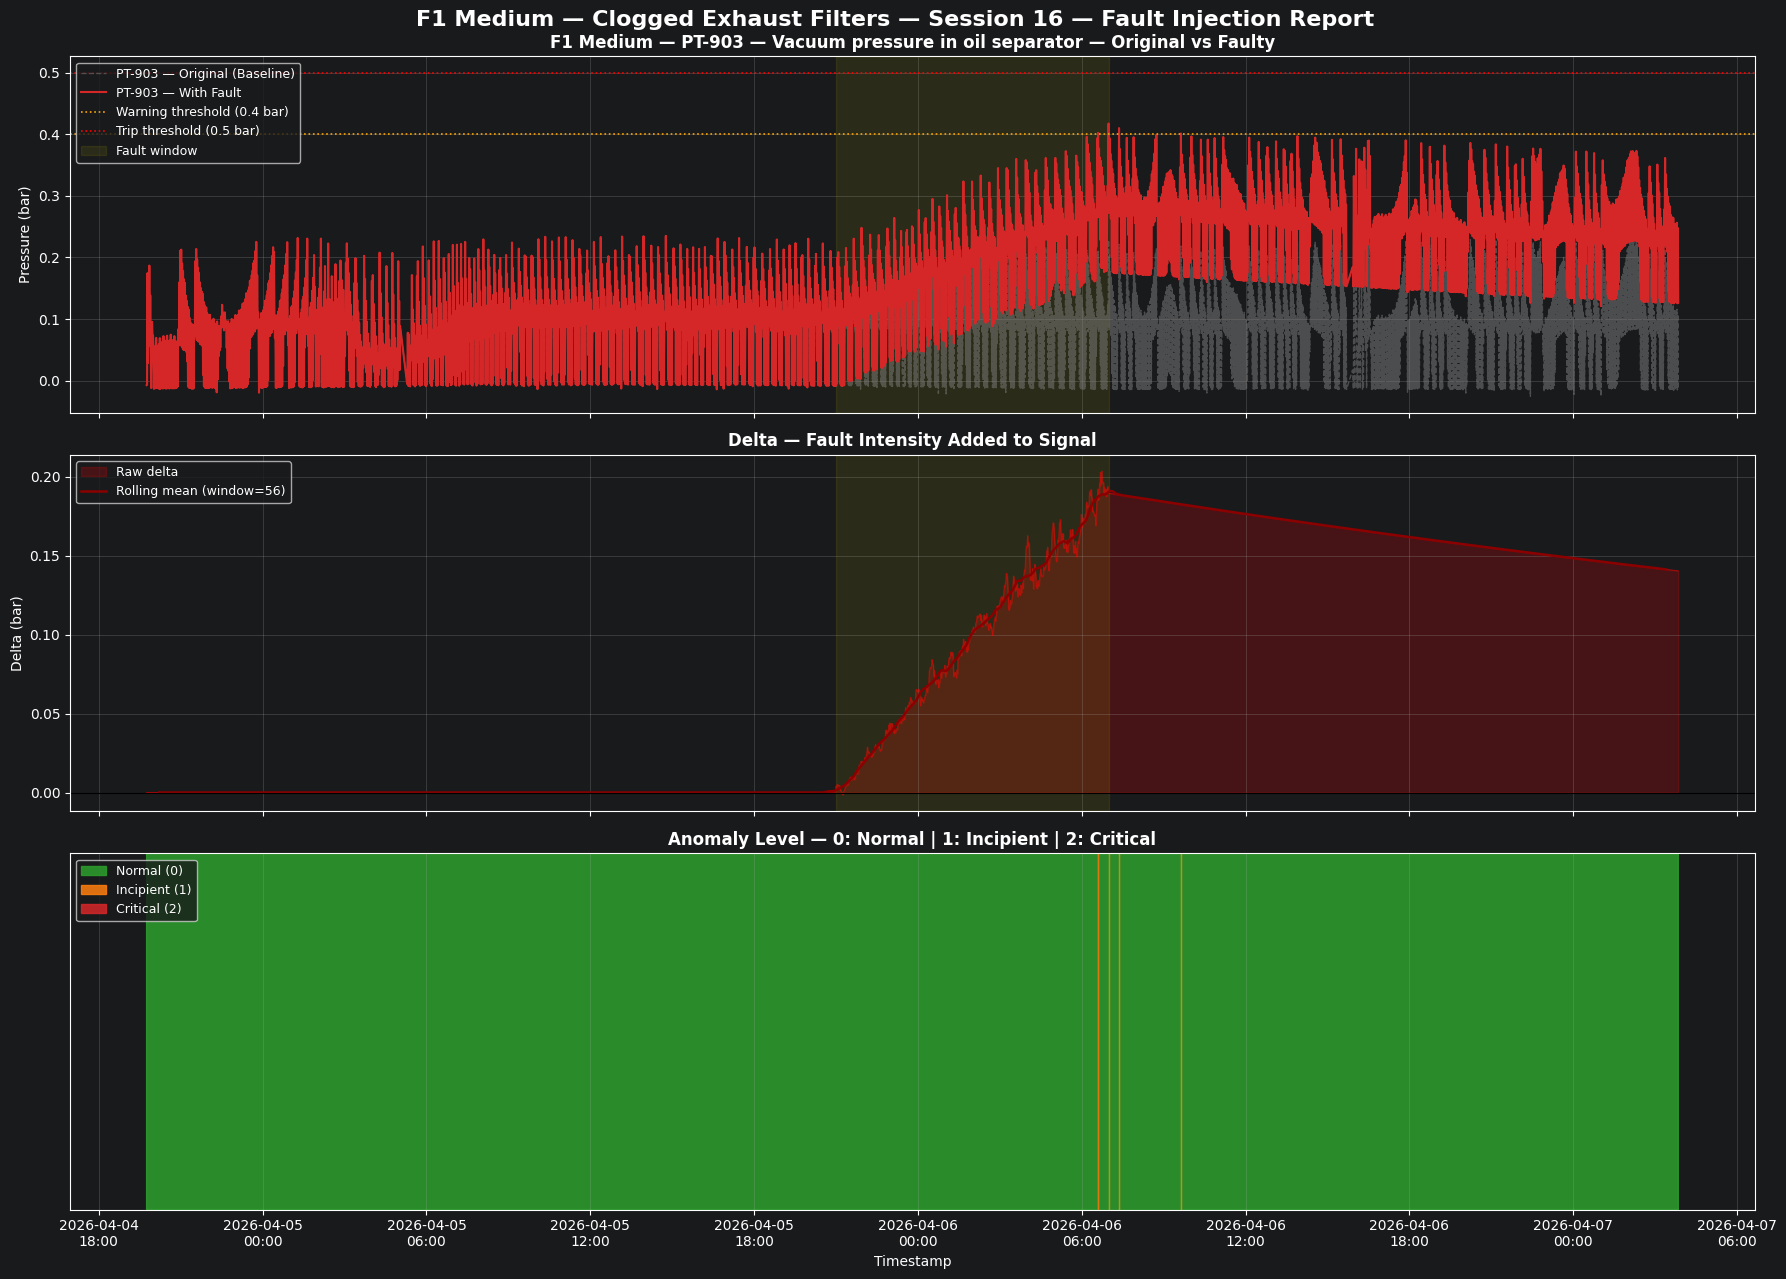

In [9]:
""" F1 Medium — Fault Profile Verification Plot — Session 16 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty PT-903
# ============================================================

f1_medium_fault_start_timestamp = df_f1_medium_s16.index[f1_medium_start_idx]
f1_medium_fault_end_timestamp   = df_f1_medium_s16.index[f1_medium_end_idx - 1]

ax1.plot(
    df_session_16.index,
    df_session_16["PT-903"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="PT-903 — Original (Baseline)"
)

ax1.plot(
    df_f1_medium_s16.index,
    df_f1_medium_s16["PT-903"],
    color="#d62728",
    linewidth=1.5,
    label="PT-903 — With Fault"
)

ax1.axhline(
    y=pt903_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({pt903_warning} bar)"
)

ax1.axhline(
    y=pt903_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({pt903_trip} bar)"
)

ax1.axvspan(
    f1_medium_fault_start_timestamp,
    f1_medium_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F1 Medium — PT-903 — Vacuum pressure in oil separator — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Pressure (bar)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f1_medium_delta_full         = df_f1_medium_s16["PT-903"] - df_session_16["PT-903"]
f1_medium_roll_window        = max(10, len(f1_medium_delta_full) // 60)
f1_medium_delta_rolling_mean = f1_medium_delta_full.rolling(f1_medium_roll_window, center=True).mean()

ax2.fill_between(
    df_f1_medium_s16.index,
    0,
    f1_medium_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    df_f1_medium_s16.index,
    f1_medium_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    df_f1_medium_s16.index,
    f1_medium_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f1_medium_roll_window})"
)

ax2.axhline(
    y=0,
    color="black",
    linewidth=0.8
)

ax2.axvspan(
    f1_medium_fault_start_timestamp,
    f1_medium_fault_end_timestamp,
    color="yellow",
    alpha=0.08
)

ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (bar)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f1_medium_normal_mask    = df_f1_medium_s16["anomaly_level"] == 0
f1_medium_incipient_mask = df_f1_medium_s16["anomaly_level"] == 1
f1_medium_critical_mask  = df_f1_medium_s16["anomaly_level"] == 2

ax3.fill_between(
    df_f1_medium_s16.index,
    0, 1,
    where=f1_medium_normal_mask,
    color="#2ca02c",
    step="mid",
    alpha=0.85,
    label="Normal (0)"
)

ax3.fill_between(
    df_f1_medium_s16.index,
    0, 1,
    where=f1_medium_incipient_mask,
    color="#ff7f0e",
    step="mid",
    alpha=0.85,
    label="Incipient (1)"
)

ax3.fill_between(
    df_f1_medium_s16.index,
    0, 1,
    where=f1_medium_critical_mask,
    color="#d62728",
    step="mid",
    alpha=0.85,
    label="Critical (2)"
)

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F1 Medium — Clogged Exhaust Filters — Session 16 — Fault Injection Report", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

#### Severe

In [10]:
""" F1 Severe — Clogged Exhaust Filters — Session 16 """

np.random.seed(42)

# ============================================================
# BASE SESSION
# ============================================================

df_session_16 = dict_sessions[16].copy()

# ============================================================
# FAULT PARAMETERS
# ============================================================

f1_severe_main_sensor    = "PT-903"
f1_severe_session_length = len(df_session_16)
f1_severe_start_from     = 0.55
f1_severe_length_hours   = 12
f1_severe_smooth_window  = 10

f1_severe_start_idx = int(round(f1_severe_session_length * f1_severe_start_from))
f1_severe_end_idx   = min(f1_severe_start_idx + int(round(f1_severe_length_hours * 60)), f1_severe_session_length)
f1_severe_total_l   = f1_severe_end_idx - f1_severe_start_idx

print(f"Session 16 length:       {f1_severe_session_length} rows")
print(f"Fault start index:       {f1_severe_start_idx}")
print(f"Fault end index:         {f1_severe_end_idx}")
print(f"Fault window length:     {f1_severe_total_l} rows")

# ============================================================
# BASELINE — computed on pre-fault window
# ============================================================

f1_severe_baseline_mean = df_session_16["PT-903"].iloc[:f1_severe_start_idx].mean()
f1_severe_baseline_std  = df_session_16["PT-903"].iloc[:f1_severe_start_idx].std()

print(f"\nPT-903 baseline mean:    {f1_severe_baseline_mean:.4f} bar")
print(f"PT-903 baseline std:     {f1_severe_baseline_std:.4f} bar")

# ============================================================
# SEVERITY TARGET — severe = trip level
# ============================================================

f1_severe_target    = pt903_trip
f1_severe_delta_mag = f1_severe_target - f1_severe_baseline_mean

print(f"PT-903 severe target:    {f1_severe_target:.4f} bar")
print(f"PT-903 delta magnitude:  {f1_severe_delta_mag:.4f} bar")

# ============================================================
# DELTA SHAPE — ramp with noise
# ============================================================

f1_severe_trend       = np.linspace(0, f1_severe_delta_mag, f1_severe_total_l)
f1_severe_noise_scale = np.linspace(f1_severe_baseline_std * 0.1, f1_severe_baseline_std * 0.5, f1_severe_total_l)
f1_severe_noise       = np.random.normal(0, f1_severe_noise_scale, f1_severe_total_l)
f1_severe_ramp        = f1_severe_trend + f1_severe_noise
f1_severe_delta       = pd.Series(f1_severe_ramp).rolling(f1_severe_smooth_window, center=True, min_periods=1).mean().values

# ============================================================
# CORRELATION — computed on full session
# ============================================================

f1_severe_corr_threshold = 0.70
f1_severe_corr           = df_session_16.corr(method="pearson", numeric_only=True)["PT-903"]
f1_severe_corr_sensors   = f1_severe_corr[abs(f1_severe_corr) >= f1_severe_corr_threshold].index.tolist()

print(f"\nCorrelated sensors (|r| >= {f1_severe_corr_threshold}): {f1_severe_corr_sensors}")

# ============================================================
# INJECT FAULT
# ============================================================

df_f1_severe_s16 = df_session_16.copy()

f1_severe_propagation_scale = 0.25

for sensor in f1_severe_corr_sensors:
    if sensor in df_f1_severe_s16.columns:
        scale = 1.0 if sensor == f1_severe_main_sensor else f1_severe_propagation_scale
        df_f1_severe_s16.iloc[f1_severe_start_idx:f1_severe_end_idx, df_f1_severe_s16.columns.get_loc(sensor)] += f1_severe_delta * f1_severe_corr[sensor] * scale

# ============================================================
# DECAY PHASE
# ============================================================

f1_severe_decay_rate = 0.3
f1_severe_remaining  = f1_severe_session_length - f1_severe_end_idx
f1_severe_decay      = f1_severe_delta[-1] * np.exp(-f1_severe_decay_rate * np.linspace(0, 1, f1_severe_remaining))

for sensor in f1_severe_corr_sensors:
    if sensor in df_f1_severe_s16.columns:
        scale = 1.0 if sensor == f1_severe_main_sensor else f1_severe_propagation_scale
        df_f1_severe_s16.iloc[f1_severe_end_idx:, df_f1_severe_s16.columns.get_loc(sensor)] += f1_severe_decay * f1_severe_corr[sensor] * scale

# ============================================================
# LABELS
# ============================================================

df_f1_severe_s16["anomaly_level"]       = 0
df_f1_severe_s16["is_injected_anomaly"] = 0
df_f1_severe_s16["anomaly_type"]        = "normal"

f1_severe_injected_values = df_f1_severe_s16["PT-903"].iloc[f1_severe_start_idx:]

f1_severe_labels = np.where(
    f1_severe_injected_values >= pt903_trip,    2,
    np.where(
    f1_severe_injected_values >= pt903_warning, 1,
                                                0)
)

df_f1_severe_s16.iloc[f1_severe_start_idx:, df_f1_severe_s16.columns.get_loc("anomaly_level")]       = f1_severe_labels
df_f1_severe_s16.iloc[f1_severe_start_idx:, df_f1_severe_s16.columns.get_loc("is_injected_anomaly")] = 1
df_f1_severe_s16.iloc[f1_severe_start_idx:, df_f1_severe_s16.columns.get_loc("anomaly_type")]        = "clogged_filters"

# ============================================================
# SAVE
# ============================================================

df_f1_severe_s16.to_csv(f"{output_dir_single}/session_16_F1_severe.csv")

print(f"\nSession 16 F1 severe saved")
print(f"Anomaly rows:  {df_f1_severe_s16['is_injected_anomaly'].sum()}")
print(f"Normal rows:   {(df_f1_severe_s16['is_injected_anomaly'] == 0).sum()}")
print(f"Level 1 rows:  {(df_f1_severe_s16['anomaly_level'] == 1).sum()}")
print(f"Level 2 rows:  {(df_f1_severe_s16['anomaly_level'] == 2).sum()}")

Session 16 length:       3367 rows
Fault start index:       1852
Fault end index:         2572
Fault window length:     720 rows

PT-903 baseline mean:    0.0814 bar
PT-903 baseline std:     0.0718 bar
PT-903 severe target:    0.5000 bar
PT-903 delta magnitude:  0.4186 bar

Correlated sensors (|r| >= 0.7): ['FT-901', 'PT-901', 'PT-902', 'PT-903', 'VSD-901_CORRENT', 'VSD-901_POWER']

Session 16 F1 severe saved
Anomaly rows:  1515
Normal rows:   1852
Level 1 rows:  463
Level 2 rows:  264


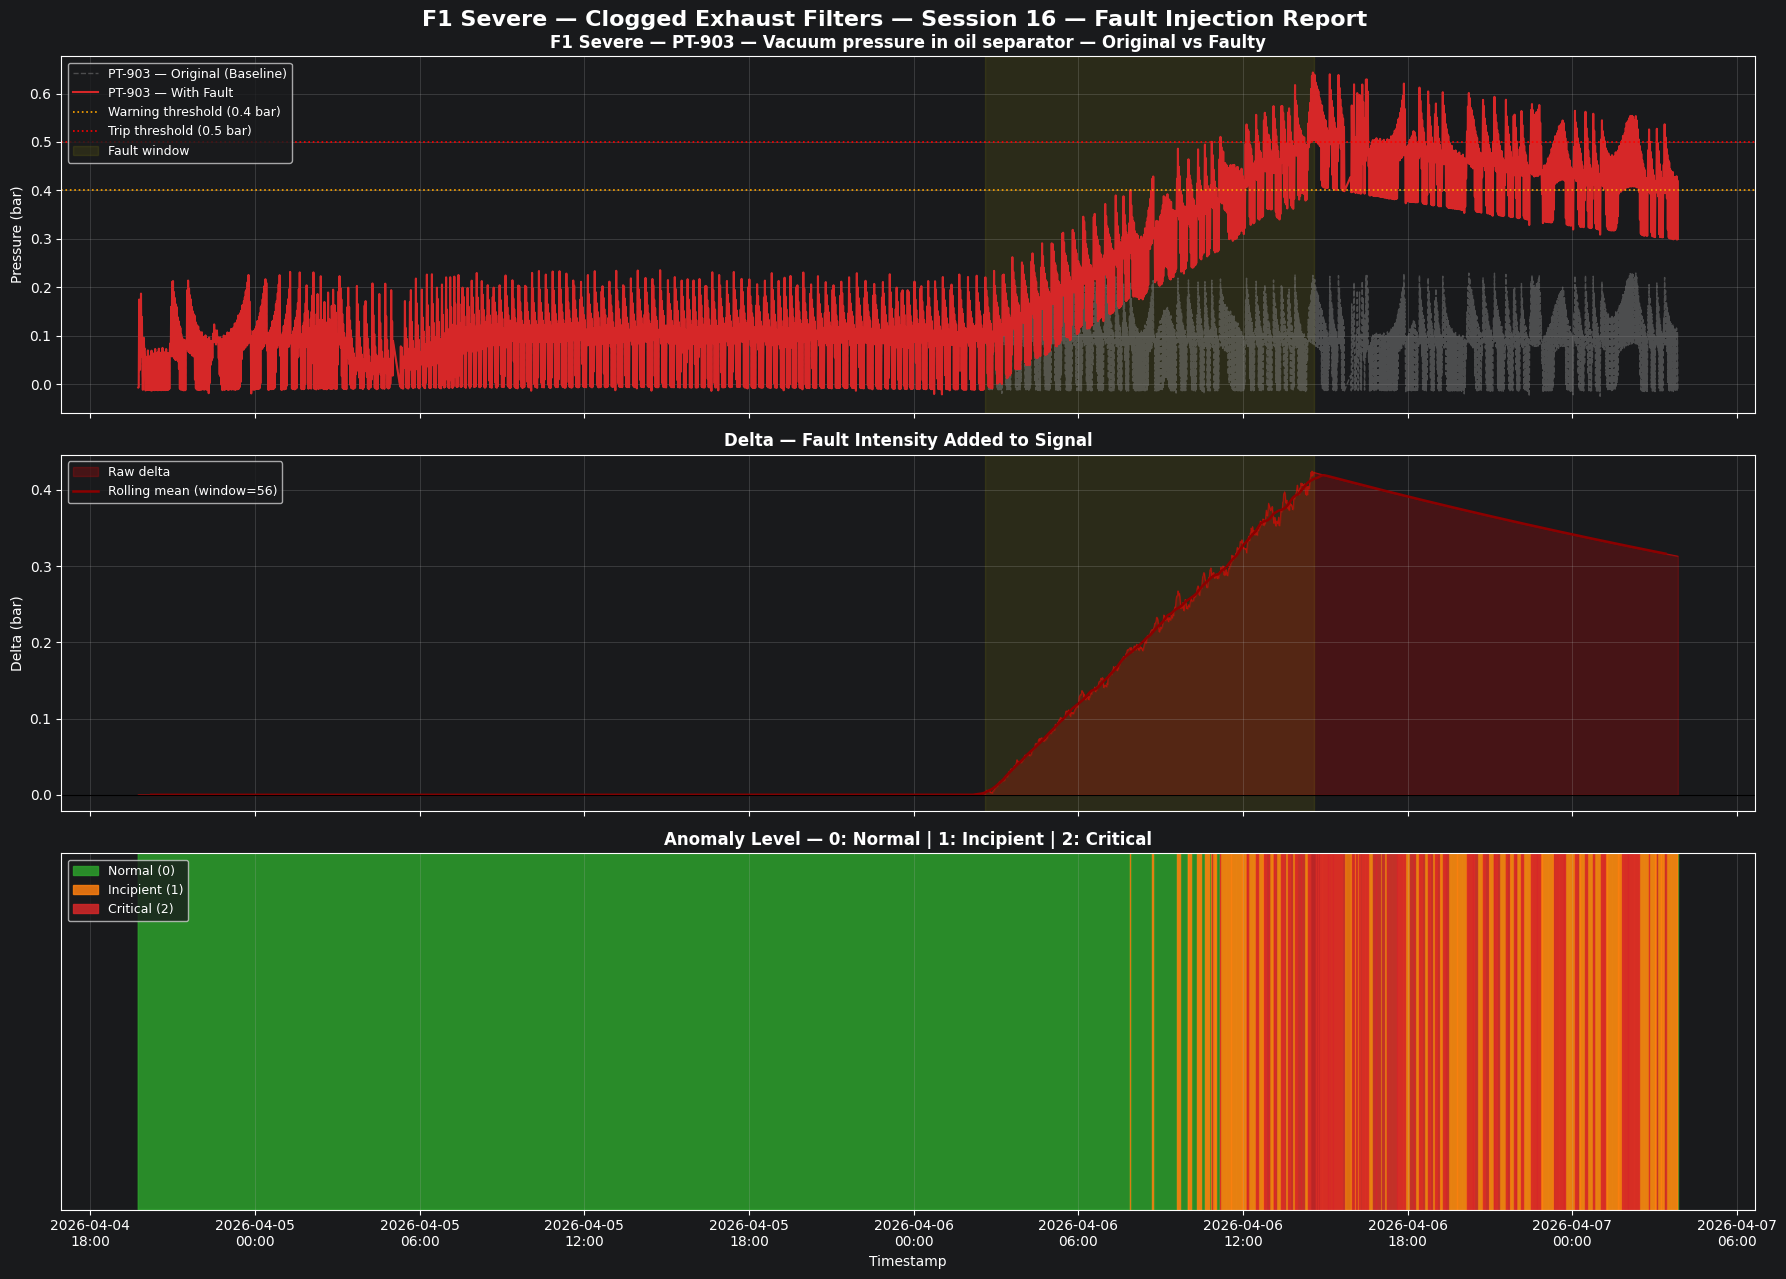

In [11]:
""" F1 Severe — Fault Profile Verification Plot — Session 16 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty PT-903
# ============================================================

f1_severe_fault_start_timestamp = df_f1_severe_s16.index[f1_severe_start_idx]
f1_severe_fault_end_timestamp   = df_f1_severe_s16.index[f1_severe_end_idx - 1]

ax1.plot(
    df_session_16.index,
    df_session_16["PT-903"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="PT-903 — Original (Baseline)"
)

ax1.plot(
    df_f1_severe_s16.index,
    df_f1_severe_s16["PT-903"],
    color="#d62728",
    linewidth=1.5,
    label="PT-903 — With Fault"
)

ax1.axhline(
    y=pt903_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({pt903_warning} bar)"
)

ax1.axhline(
    y=pt903_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({pt903_trip} bar)"
)

ax1.axvspan(
    f1_severe_fault_start_timestamp,
    f1_severe_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F1 Severe — PT-903 — Vacuum pressure in oil separator — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Pressure (bar)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f1_severe_delta_full         = df_f1_severe_s16["PT-903"] - df_session_16["PT-903"]
f1_severe_roll_window        = max(10, len(f1_severe_delta_full) // 60)
f1_severe_delta_rolling_mean = f1_severe_delta_full.rolling(f1_severe_roll_window, center=True).mean()

ax2.fill_between(
    df_f1_severe_s16.index,
    0,
    f1_severe_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    df_f1_severe_s16.index,
    f1_severe_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    df_f1_severe_s16.index,
    f1_severe_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f1_severe_roll_window})"
)

ax2.axhline(
    y=0,
    color="black",
    linewidth=0.8
)

ax2.axvspan(
    f1_severe_fault_start_timestamp,
    f1_severe_fault_end_timestamp,
    color="yellow",
    alpha=0.08
)

ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (bar)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f1_severe_normal_mask    = df_f1_severe_s16["anomaly_level"] == 0
f1_severe_incipient_mask = df_f1_severe_s16["anomaly_level"] == 1
f1_severe_critical_mask  = df_f1_severe_s16["anomaly_level"] == 2

ax3.fill_between(
    df_f1_severe_s16.index,
    0, 1,
    where=f1_severe_normal_mask,
    color="#2ca02c",
    step="mid",
    alpha=0.85,
    label="Normal (0)"
)

ax3.fill_between(
    df_f1_severe_s16.index,
    0, 1,
    where=f1_severe_incipient_mask,
    color="#ff7f0e",
    step="mid",
    alpha=0.85,
    label="Incipient (1)"
)

ax3.fill_between(
    df_f1_severe_s16.index,
    0, 1,
    where=f1_severe_critical_mask,
    color="#d62728",
    step="mid",
    alpha=0.85,
    label="Critical (2)"
)

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F1 Severe — Clogged Exhaust Filters — Session 16 — Fault Injection Report", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

### F2 Fault

#### Small

In [12]:
""" F2 Small — Insufficient Cooling — Session 16 """

np.random.seed(42)

# ============================================================
# BASE SESSION
# ============================================================

df_session_16 = dict_sessions[16].copy()

# ============================================================
# FAULT PARAMETERS
# ============================================================

f2_small_main_sensor    = "TT-901"
f2_small_session_length = len(df_session_16)
f2_small_start_from     = 0.30
f2_small_length_hours   = 6
f2_small_smooth_window  = 20

f2_small_start_idx = int(round(f2_small_session_length * f2_small_start_from))
f2_small_end_idx   = min(f2_small_start_idx + int(round(f2_small_length_hours * 60)), f2_small_session_length)
f2_small_total_l   = f2_small_end_idx - f2_small_start_idx

print(f"Session 16 length:       {f2_small_session_length} rows")
print(f"Fault start index:       {f2_small_start_idx}")
print(f"Fault end index:         {f2_small_end_idx}")
print(f"Fault window length:     {f2_small_total_l} rows")

# ============================================================
# BASELINE — computed on pre-fault window
# ============================================================

f2_small_baseline_mean = df_session_16["TT-901"].iloc[:f2_small_start_idx].mean()
f2_small_baseline_std  = df_session_16["TT-901"].iloc[:f2_small_start_idx].std()

print(f"\nTT-901 baseline mean:    {f2_small_baseline_mean:.4f} °C")
print(f"TT-901 baseline std:     {f2_small_baseline_std:.4f} °C")

# ============================================================
# SEVERITY TARGET — small = 25% of warning level
# ============================================================

f2_small_amplitude = tt901_warning * 0.25     # 33.75°C

print(f"TT-901 small amplitude:  {f2_small_amplitude:.4f} °C")

# ============================================================
# DELTA SHAPE — micro ramp (smoothstep)
# ============================================================

f2_small_t          = np.linspace(0, 1, f2_small_total_l)
f2_small_smoothstep = 3 * f2_small_t**2 - 2 * f2_small_t**3
f2_small_noise      = np.random.normal(0, f2_small_baseline_std * 0.08, f2_small_total_l)
f2_small_noise      = pd.Series(f2_small_noise).rolling(f2_small_smooth_window, center=True, min_periods=1).mean().values
f2_small_delta      = f2_small_amplitude * f2_small_smoothstep + f2_small_noise

# ============================================================
# CORRELATION — computed on full session
# ============================================================

f2_small_corr_threshold = 0.60
f2_small_corr           = df_session_16.corr(method="pearson", numeric_only=True)["TT-901"]
f2_small_corr_sensors   = f2_small_corr[abs(f2_small_corr) >= f2_small_corr_threshold].index.tolist()

print(f"\nCorrelated sensors (|r| >= {f2_small_corr_threshold}): {f2_small_corr_sensors}")

# ============================================================
# INJECT FAULT
# ============================================================

df_f2_small_s16 = df_session_16.copy()

f2_small_propagation_scale = 0.30

for sensor in f2_small_corr_sensors:
    if sensor in df_f2_small_s16.columns:
        scale = 1.0 if sensor == f2_small_main_sensor else f2_small_propagation_scale
        df_f2_small_s16.iloc[f2_small_start_idx:f2_small_end_idx, df_f2_small_s16.columns.get_loc(sensor)] += f2_small_delta * f2_small_corr[sensor] * scale

# ============================================================
# DECAY PHASE
# ============================================================

f2_small_decay_rate = 1.2
f2_small_remaining  = f2_small_session_length - f2_small_end_idx
f2_small_decay      = f2_small_delta[-1] * np.exp(-f2_small_decay_rate * np.linspace(0, 1, f2_small_remaining))

for sensor in f2_small_corr_sensors:
    if sensor in df_f2_small_s16.columns:
        scale = 1.0 if sensor == f2_small_main_sensor else f2_small_propagation_scale
        df_f2_small_s16.iloc[f2_small_end_idx:, df_f2_small_s16.columns.get_loc(sensor)] += f2_small_decay * f2_small_corr[sensor] * scale

# ============================================================
# LABELS
# ============================================================

df_f2_small_s16["anomaly_level"]       = 0
df_f2_small_s16["is_injected_anomaly"] = 0
df_f2_small_s16["anomaly_type"]        = "normal"

df_f2_small_s16.iloc[f2_small_start_idx:f2_small_end_idx, df_f2_small_s16.columns.get_loc("anomaly_level")]       = 1
df_f2_small_s16.iloc[f2_small_start_idx:f2_small_end_idx, df_f2_small_s16.columns.get_loc("is_injected_anomaly")] = 1
df_f2_small_s16.iloc[f2_small_start_idx:f2_small_end_idx, df_f2_small_s16.columns.get_loc("anomaly_type")]        = "cooling_fault"

# ============================================================
# SAVE
# ============================================================

df_f2_small_s16.to_csv(f"{output_dir_single}/session_16_F2_small.csv")

print(f"\nSession 16 F2 small saved")
print(f"Anomaly rows:  {df_f2_small_s16['is_injected_anomaly'].sum()}")
print(f"Normal rows:   {(df_f2_small_s16['is_injected_anomaly'] == 0).sum()}")

Session 16 length:       3367 rows
Fault start index:       1010
Fault end index:         1370
Fault window length:     360 rows

TT-901 baseline mean:    61.6339 °C
TT-901 baseline std:     3.3815 °C
TT-901 small amplitude:  33.7500 °C

Correlated sensors (|r| >= 0.6): ['TT-901', 'TT-902', 'TT-903', 'TT-904']

Session 16 F2 small saved
Anomaly rows:  360
Normal rows:   3007


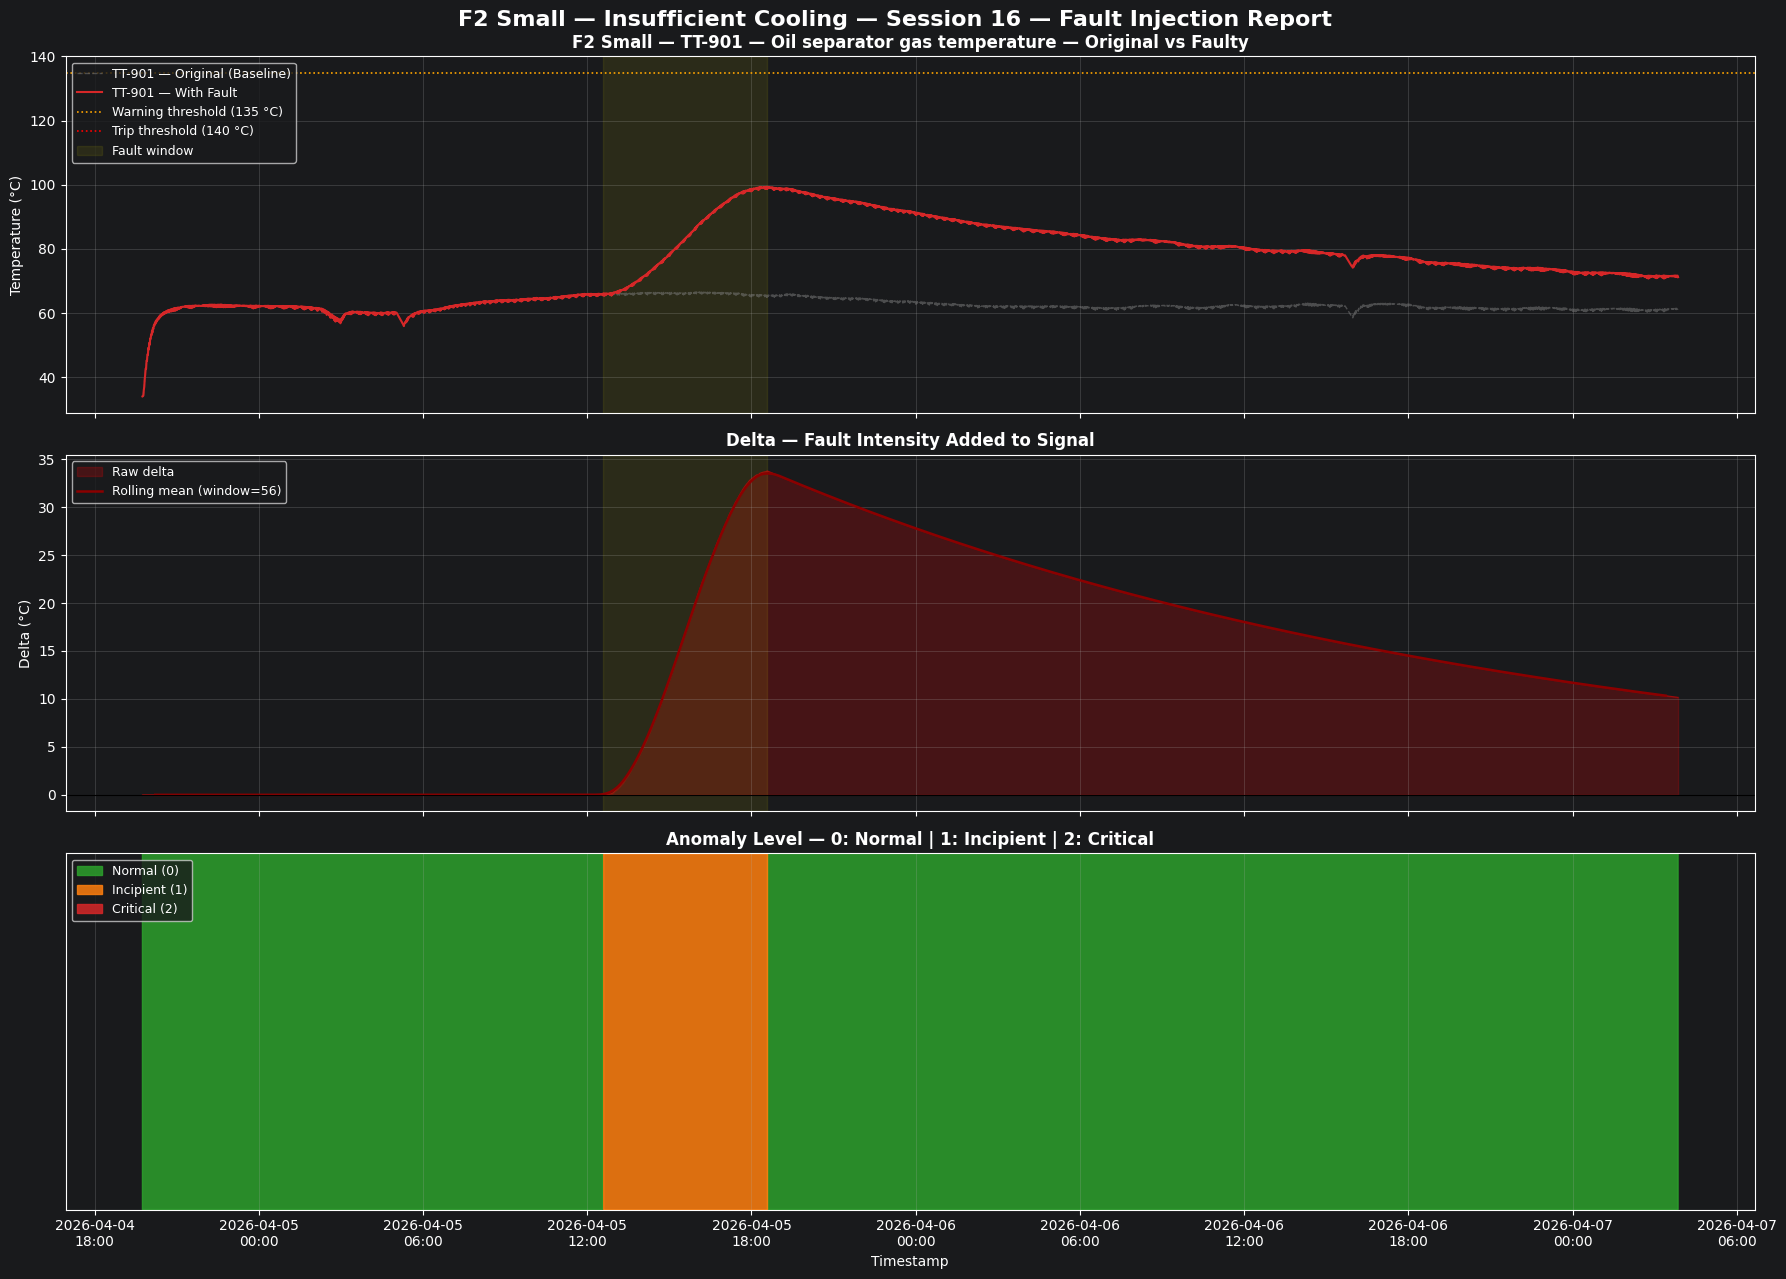

In [13]:
""" F2 Small — Fault Profile Verification Plot — Session 16 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty TT-901
# ============================================================

f2_small_fault_start_timestamp = df_f2_small_s16.index[f2_small_start_idx]
f2_small_fault_end_timestamp   = df_f2_small_s16.index[f2_small_end_idx - 1]

ax1.plot(
    df_session_16.index,
    df_session_16["TT-901"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="TT-901 — Original (Baseline)"
)

ax1.plot(
    df_f2_small_s16.index,
    df_f2_small_s16["TT-901"],
    color="#d62728",
    linewidth=1.5,
    label="TT-901 — With Fault"
)

ax1.axhline(
    y=tt901_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({tt901_warning} °C)"
)

ax1.axhline(
    y=tt901_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({tt901_trip} °C)"
)

ax1.axvspan(
    f2_small_fault_start_timestamp,
    f2_small_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F2 Small — TT-901 — Oil separator gas temperature — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Temperature (°C)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f2_small_delta_full         = df_f2_small_s16["TT-901"] - df_session_16["TT-901"]
f2_small_roll_window        = max(10, len(f2_small_delta_full) // 60)
f2_small_delta_rolling_mean = f2_small_delta_full.rolling(f2_small_roll_window, center=True).mean()

ax2.fill_between(
    df_f2_small_s16.index,
    0,
    f2_small_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    df_f2_small_s16.index,
    f2_small_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    df_f2_small_s16.index,
    f2_small_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f2_small_roll_window})"
)

ax2.axhline(
    y=0,
    color="black",
    linewidth=0.8
)

ax2.axvspan(
    f2_small_fault_start_timestamp,
    f2_small_fault_end_timestamp,
    color="yellow",
    alpha=0.08
)

ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (°C)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f2_small_normal_mask    = df_f2_small_s16["anomaly_level"] == 0
f2_small_incipient_mask = df_f2_small_s16["anomaly_level"] == 1
f2_small_critical_mask  = df_f2_small_s16["anomaly_level"] == 2

ax3.fill_between(
    df_f2_small_s16.index,
    0, 1,
    where=f2_small_normal_mask,
    color="#2ca02c",
    step="mid",
    alpha=0.85,
    label="Normal (0)"
)

ax3.fill_between(
    df_f2_small_s16.index,
    0, 1,
    where=f2_small_incipient_mask,
    color="#ff7f0e",
    step="mid",
    alpha=0.85,
    label="Incipient (1)"
)

ax3.fill_between(
    df_f2_small_s16.index,
    0, 1,
    where=f2_small_critical_mask,
    color="#d62728",
    step="mid",
    alpha=0.85,
    label="Critical (2)"
)

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F2 Small — Insufficient Cooling — Session 16 — Fault Injection Report", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

#### Medium

In [14]:
""" F2 Medium — Insufficient Cooling — Session 16 """

np.random.seed(42)

# ============================================================
# BASE SESSION
# ============================================================

df_session_16 = dict_sessions[16].copy()

# ============================================================
# FAULT PARAMETERS
# ============================================================

f2_medium_main_sensor    = "TT-901"
f2_medium_session_length = len(df_session_16)
f2_medium_start_from     = 0.45
f2_medium_length_hours   = 5
f2_medium_smooth_window  = 10

f2_medium_start_idx = int(round(f2_medium_session_length * f2_medium_start_from))
f2_medium_end_idx   = min(f2_medium_start_idx + int(round(f2_medium_length_hours * 60)), f2_medium_session_length)
f2_medium_total_l   = f2_medium_end_idx - f2_medium_start_idx

print(f"Session 16 length:       {f2_medium_session_length} rows")
print(f"Fault start index:       {f2_medium_start_idx}")
print(f"Fault end index:         {f2_medium_end_idx}")
print(f"Fault window length:     {f2_medium_total_l} rows")

# ============================================================
# BASELINE — computed on pre-fault window
# ============================================================

f2_medium_baseline_mean = df_session_16["TT-901"].iloc[:f2_medium_start_idx].mean()
f2_medium_baseline_std  = df_session_16["TT-901"].iloc[:f2_medium_start_idx].std()

print(f"\nTT-901 baseline mean:    {f2_medium_baseline_mean:.4f} °C")
print(f"TT-901 baseline std:     {f2_medium_baseline_std:.4f} °C")

# ============================================================
# SEVERITY TARGET — medium = trip * 0.55
# ============================================================

f2_medium_target    = tt901_trip * 0.55
f2_medium_delta_mag = f2_medium_target - f2_medium_baseline_mean

print(f"TT-901 medium target:    {f2_medium_target:.4f} °C")
print(f"TT-901 delta magnitude:  {f2_medium_delta_mag:.4f} °C")

# ============================================================
# DELTA SHAPE — ramp with noise
# ============================================================

f2_medium_trend       = np.linspace(0, f2_medium_delta_mag, f2_medium_total_l)
f2_medium_noise_scale = np.linspace(f2_medium_baseline_std * 0.1, f2_medium_baseline_std * 0.5, f2_medium_total_l)
f2_medium_noise       = np.random.normal(0, f2_medium_noise_scale, f2_medium_total_l)
f2_medium_ramp        = f2_medium_trend + f2_medium_noise
f2_medium_delta       = pd.Series(f2_medium_ramp).rolling(f2_medium_smooth_window, center=True, min_periods=1).mean().values

# ============================================================
# CORRELATION — computed on full session
# ============================================================

f2_medium_corr_threshold = 0.60
f2_medium_corr           = df_session_16.corr(method="pearson", numeric_only=True)["TT-901"]
f2_medium_corr_sensors   = f2_medium_corr[abs(f2_medium_corr) >= f2_medium_corr_threshold].index.tolist()

print(f"\nCorrelated sensors (|r| >= {f2_medium_corr_threshold}): {f2_medium_corr_sensors}")

# ============================================================
# INJECT FAULT
# ============================================================

df_f2_medium_s16 = df_session_16.copy()

f2_medium_propagation_scale = 0.30

for sensor in f2_medium_corr_sensors:
    if sensor in df_f2_medium_s16.columns:
        scale = 1.0 if sensor == f2_medium_main_sensor else f2_medium_propagation_scale
        df_f2_medium_s16.iloc[f2_medium_start_idx:f2_medium_end_idx, df_f2_medium_s16.columns.get_loc(sensor)] += f2_medium_delta * f2_medium_corr[sensor] * scale

# ============================================================
# DECAY PHASE
# ============================================================

f2_medium_decay_rate = 0.3
f2_medium_remaining  = f2_medium_session_length - f2_medium_end_idx
f2_medium_decay      = f2_medium_delta[-1] * np.exp(-f2_medium_decay_rate * np.linspace(0, 1, f2_medium_remaining))

for sensor in f2_medium_corr_sensors:
    if sensor in df_f2_medium_s16.columns:
        scale = 1.0 if sensor == f2_medium_main_sensor else f2_medium_propagation_scale
        df_f2_medium_s16.iloc[f2_medium_end_idx:, df_f2_medium_s16.columns.get_loc(sensor)] += f2_medium_decay * f2_medium_corr[sensor] * scale

# ============================================================
# LABELS
# ============================================================

df_f2_medium_s16["anomaly_level"]       = 0
df_f2_medium_s16["is_injected_anomaly"] = 0
df_f2_medium_s16["anomaly_type"]        = "normal"

f2_medium_injected_values = df_f2_medium_s16["TT-901"].iloc[f2_medium_start_idx:]

f2_medium_labels = np.where(
    f2_medium_injected_values >= tt901_trip,    2,
    np.where(
    f2_medium_injected_values >= tt901_warning, 1,
                                                0)
)

df_f2_medium_s16.iloc[f2_medium_start_idx:, df_f2_medium_s16.columns.get_loc("anomaly_level")]       = f2_medium_labels
df_f2_medium_s16.iloc[f2_medium_start_idx:, df_f2_medium_s16.columns.get_loc("is_injected_anomaly")] = 1
df_f2_medium_s16.iloc[f2_medium_start_idx:, df_f2_medium_s16.columns.get_loc("anomaly_type")]        = "cooling_fault"

# ============================================================
# SAVE
# ============================================================

df_f2_medium_s16.to_csv(f"{output_dir_single}/session_16_F2_medium.csv")

print(f"\nSession 16 F2 medium saved")
print(f"Anomaly rows:  {df_f2_medium_s16['is_injected_anomaly'].sum()}")
print(f"Normal rows:   {(df_f2_medium_s16['is_injected_anomaly'] == 0).sum()}")
print(f"Level 1 rows:  {(df_f2_medium_s16['anomaly_level'] == 1).sum()}")
print(f"Level 2 rows:  {(df_f2_medium_s16['anomaly_level'] == 2).sum()}")

Session 16 length:       3367 rows
Fault start index:       1515
Fault end index:         1815
Fault window length:     300 rows

TT-901 baseline mean:    63.0318 °C
TT-901 baseline std:     3.4083 °C
TT-901 medium target:    77.0000 °C
TT-901 delta magnitude:  13.9682 °C

Correlated sensors (|r| >= 0.6): ['TT-901', 'TT-902', 'TT-903', 'TT-904']

Session 16 F2 medium saved
Anomaly rows:  1852
Normal rows:   1515
Level 1 rows:  0
Level 2 rows:  0


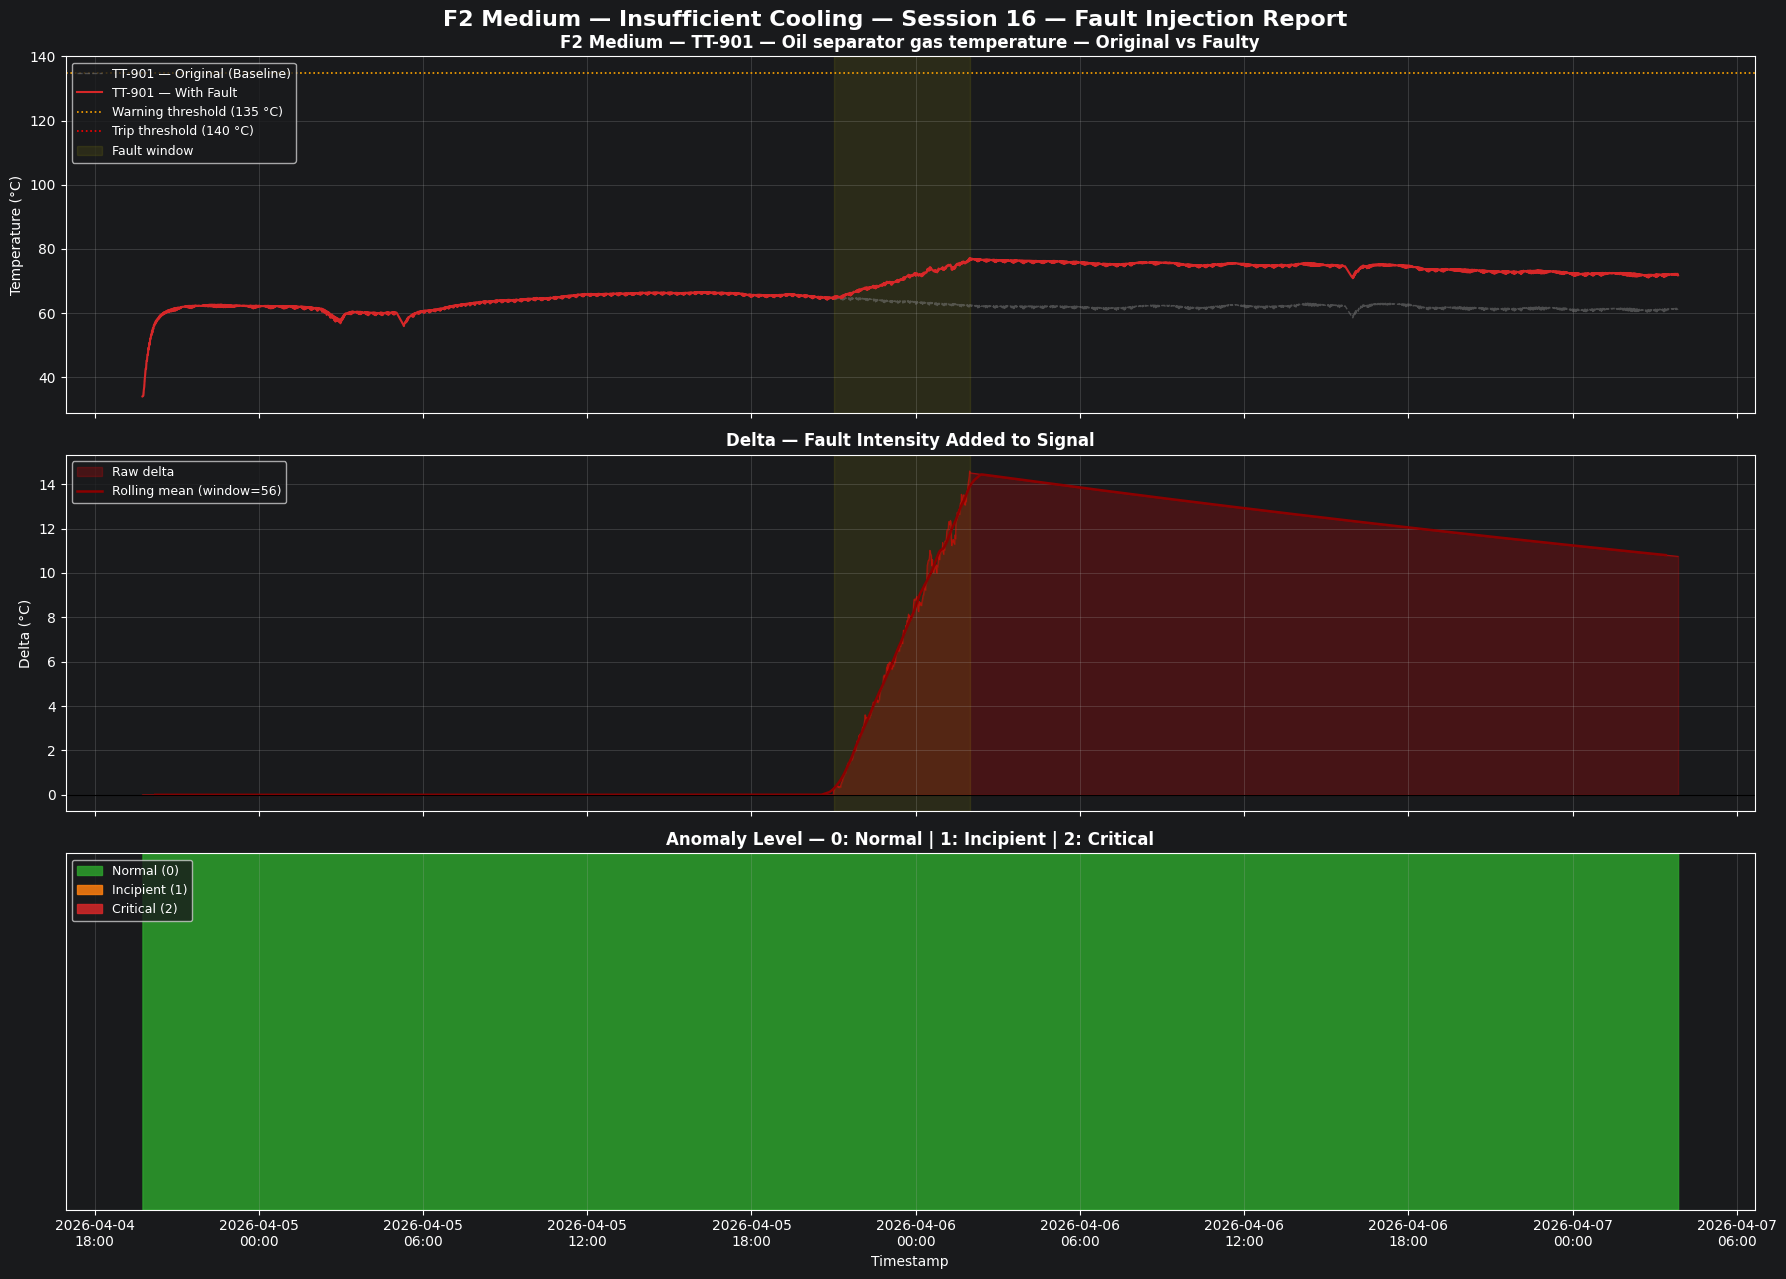

In [15]:
""" F2 Medium — Fault Profile Verification Plot — Session 16 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty TT-901
# ============================================================

f2_medium_fault_start_timestamp = df_f2_medium_s16.index[f2_medium_start_idx]
f2_medium_fault_end_timestamp   = df_f2_medium_s16.index[f2_medium_end_idx - 1]

ax1.plot(
    df_session_16.index,
    df_session_16["TT-901"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="TT-901 — Original (Baseline)"
)

ax1.plot(
    df_f2_medium_s16.index,
    df_f2_medium_s16["TT-901"],
    color="#d62728",
    linewidth=1.5,
    label="TT-901 — With Fault"
)

ax1.axhline(
    y=tt901_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({tt901_warning} °C)"
)

ax1.axhline(
    y=tt901_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({tt901_trip} °C)"
)

ax1.axvspan(
    f2_medium_fault_start_timestamp,
    f2_medium_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F2 Medium — TT-901 — Oil separator gas temperature — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Temperature (°C)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f2_medium_delta_full         = df_f2_medium_s16["TT-901"] - df_session_16["TT-901"]
f2_medium_roll_window        = max(10, len(f2_medium_delta_full) // 60)
f2_medium_delta_rolling_mean = f2_medium_delta_full.rolling(f2_medium_roll_window, center=True).mean()

ax2.fill_between(
    df_f2_medium_s16.index,
    0,
    f2_medium_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    df_f2_medium_s16.index,
    f2_medium_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    df_f2_medium_s16.index,
    f2_medium_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f2_medium_roll_window})"
)

ax2.axhline(
    y=0,
    color="black",
    linewidth=0.8
)

ax2.axvspan(
    f2_medium_fault_start_timestamp,
    f2_medium_fault_end_timestamp,
    color="yellow",
    alpha=0.08
)

ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (°C)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f2_medium_normal_mask    = df_f2_medium_s16["anomaly_level"] == 0
f2_medium_incipient_mask = df_f2_medium_s16["anomaly_level"] == 1
f2_medium_critical_mask  = df_f2_medium_s16["anomaly_level"] == 2

ax3.fill_between(
    df_f2_medium_s16.index,
    0, 1,
    where=f2_medium_normal_mask,
    color="#2ca02c",
    step="mid",
    alpha=0.85,
    label="Normal (0)"
)

ax3.fill_between(
    df_f2_medium_s16.index,
    0, 1,
    where=f2_medium_incipient_mask,
    color="#ff7f0e",
    step="mid",
    alpha=0.85,
    label="Incipient (1)"
)

ax3.fill_between(
    df_f2_medium_s16.index,
    0, 1,
    where=f2_medium_critical_mask,
    color="#d62728",
    step="mid",
    alpha=0.85,
    label="Critical (2)"
)

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F2 Medium — Insufficient Cooling — Session 16 — Fault Injection Report", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

#### Severe

In [16]:
""" F2 Severe — Insufficient Cooling — Session 16 """

np.random.seed(42)

# ============================================================
# BASE SESSION
# ============================================================

df_session_16 = dict_sessions[16].copy()

# ============================================================
# FAULT PARAMETERS
# ============================================================

f2_severe_main_sensor    = "TT-901"
f2_severe_session_length = len(df_session_16)
f2_severe_start_from     = 0.10
f2_severe_length_hours   = 8
f2_severe_smooth_window  = 10

f2_severe_start_idx = int(round(f2_severe_session_length * f2_severe_start_from))
f2_severe_end_idx   = min(f2_severe_start_idx + int(round(f2_severe_length_hours * 60)), f2_severe_session_length)
f2_severe_total_l   = f2_severe_end_idx - f2_severe_start_idx

print(f"Session 16 length:       {f2_severe_session_length} rows")
print(f"Fault start index:       {f2_severe_start_idx}")
print(f"Fault end index:         {f2_severe_end_idx}")
print(f"Fault window length:     {f2_severe_total_l} rows")

# ============================================================
# BASELINE — computed on pre-fault window
# ============================================================

f2_severe_baseline_mean = df_session_16["TT-901"].iloc[:f2_severe_start_idx].mean()
f2_severe_baseline_std  = df_session_16["TT-901"].iloc[:f2_severe_start_idx].std()

print(f"\nTT-901 baseline mean:    {f2_severe_baseline_mean:.4f} °C")
print(f"TT-901 baseline std:     {f2_severe_baseline_std:.4f} °C")

# ============================================================
# SEVERITY TARGET — severe = trip level
# ============================================================

f2_severe_target    = tt901_trip
f2_severe_delta_mag = f2_severe_target - f2_severe_baseline_mean

print(f"TT-901 severe target:    {f2_severe_target:.4f} °C")
print(f"TT-901 delta magnitude:  {f2_severe_delta_mag:.4f} °C")

# ============================================================
# DELTA SHAPE — ramp with noise
# ============================================================

f2_severe_trend       = np.linspace(0, f2_severe_delta_mag, f2_severe_total_l)
f2_severe_noise_scale = np.linspace(f2_severe_baseline_std * 0.1, f2_severe_baseline_std * 0.5, f2_severe_total_l)
f2_severe_noise       = np.random.normal(0, f2_severe_noise_scale, f2_severe_total_l)
f2_severe_ramp        = f2_severe_trend + f2_severe_noise
f2_severe_delta       = pd.Series(f2_severe_ramp).rolling(f2_severe_smooth_window, center=True, min_periods=1).mean().values

# ============================================================
# CORRELATION — computed on full session
# ============================================================

f2_severe_corr_threshold = 0.60
f2_severe_corr           = df_session_16.corr(method="pearson", numeric_only=True)["TT-901"]
f2_severe_corr_sensors   = f2_severe_corr[abs(f2_severe_corr) >= f2_severe_corr_threshold].index.tolist()

print(f"\nCorrelated sensors (|r| >= {f2_severe_corr_threshold}): {f2_severe_corr_sensors}")

# ============================================================
# INJECT FAULT
# ============================================================

df_f2_severe_s16 = df_session_16.copy()

f2_severe_propagation_scale = 0.30

for sensor in f2_severe_corr_sensors:
    if sensor in df_f2_severe_s16.columns:
        scale = 1.0 if sensor == f2_severe_main_sensor else f2_severe_propagation_scale
        df_f2_severe_s16.iloc[f2_severe_start_idx:f2_severe_end_idx, df_f2_severe_s16.columns.get_loc(sensor)] += f2_severe_delta * f2_severe_corr[sensor] * scale

# ============================================================
# DECAY PHASE
# ============================================================

f2_severe_decay_rate = 0.3
f2_severe_remaining  = f2_severe_session_length - f2_severe_end_idx
f2_severe_decay      = f2_severe_delta[-1] * np.exp(-f2_severe_decay_rate * np.linspace(0, 1, f2_severe_remaining))

for sensor in f2_severe_corr_sensors:
    if sensor in df_f2_severe_s16.columns:
        scale = 1.0 if sensor == f2_severe_main_sensor else f2_severe_propagation_scale
        df_f2_severe_s16.iloc[f2_severe_end_idx:, df_f2_severe_s16.columns.get_loc(sensor)] += f2_severe_decay * f2_severe_corr[sensor] * scale

# ============================================================
# LABELS
# ============================================================

df_f2_severe_s16["anomaly_level"]       = 0
df_f2_severe_s16["is_injected_anomaly"] = 0
df_f2_severe_s16["anomaly_type"]        = "normal"

f2_severe_injected_values = df_f2_severe_s16["TT-901"].iloc[f2_severe_start_idx:]

f2_severe_labels = np.where(
    f2_severe_injected_values >= tt901_trip,    2,
    np.where(
    f2_severe_injected_values >= tt901_warning, 1,
                                                0)
)

df_f2_severe_s16.iloc[f2_severe_start_idx:, df_f2_severe_s16.columns.get_loc("anomaly_level")]       = f2_severe_labels
df_f2_severe_s16.iloc[f2_severe_start_idx:, df_f2_severe_s16.columns.get_loc("is_injected_anomaly")] = 1
df_f2_severe_s16.iloc[f2_severe_start_idx:, df_f2_severe_s16.columns.get_loc("anomaly_type")]        = "cooling_fault"

# ============================================================
# SAVE
# ============================================================

df_f2_severe_s16.to_csv(f"{output_dir_single}/session_16_F2_severe.csv")

print(f"\nSession 16 F2 severe saved")
print(f"Anomaly rows:  {df_f2_severe_s16['is_injected_anomaly'].sum()}")
print(f"Normal rows:   {(df_f2_severe_s16['is_injected_anomaly'] == 0).sum()}")
print(f"Level 1 rows:  {(df_f2_severe_s16['anomaly_level'] == 1).sum()}")
print(f"Level 2 rows:  {(df_f2_severe_s16['anomaly_level'] == 2).sum()}")

Session 16 length:       3367 rows
Fault start index:       337
Fault end index:         817
Fault window length:     480 rows

TT-901 baseline mean:    60.5571 °C
TT-901 baseline std:     4.6407 °C
TT-901 severe target:    140.0000 °C
TT-901 delta magnitude:  79.4429 °C

Correlated sensors (|r| >= 0.6): ['TT-901', 'TT-902', 'TT-903', 'TT-904']

Session 16 F2 severe saved
Anomaly rows:  3030
Normal rows:   337
Level 1 rows:  336
Level 2 rows:  700


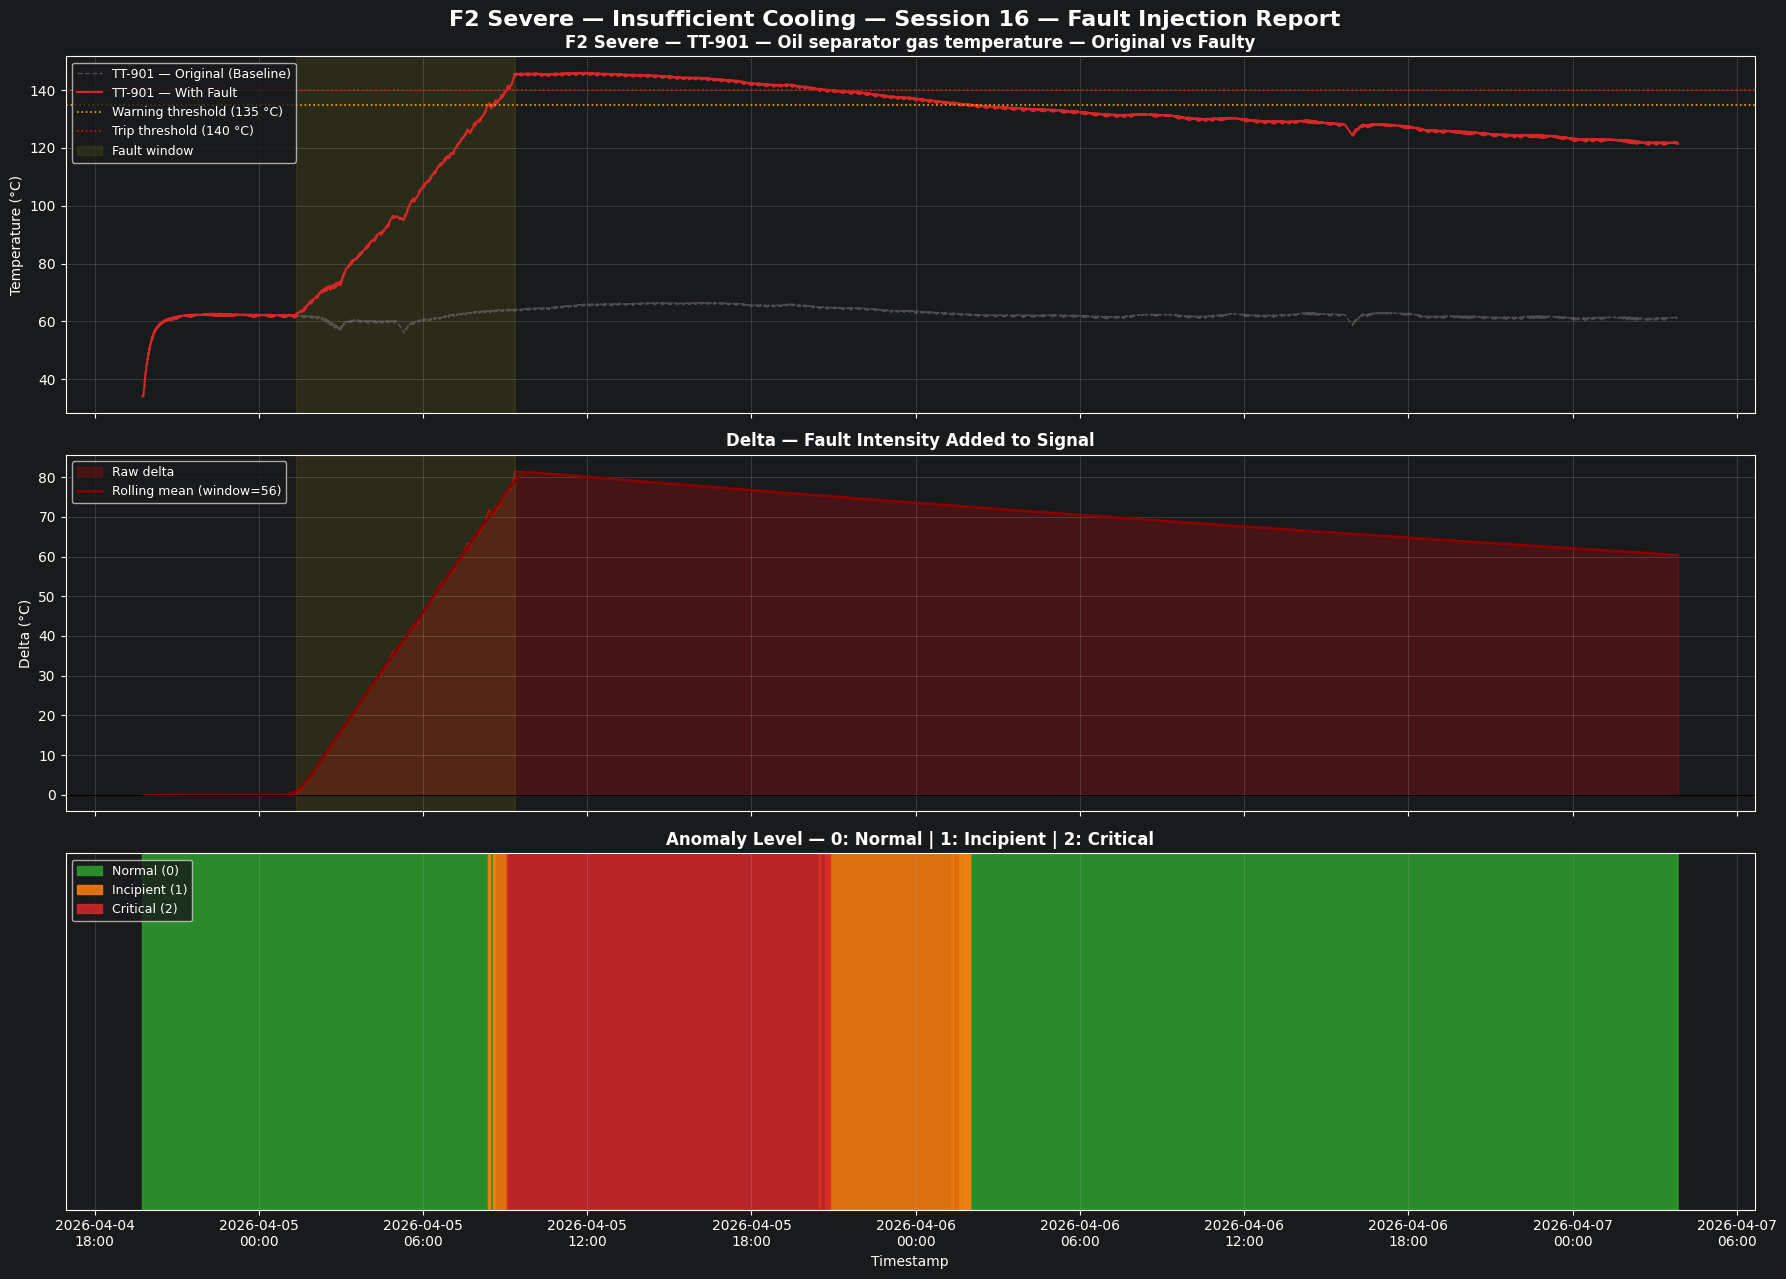

In [17]:
""" F2 Severe — Fault Profile Verification Plot — Session 16 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty TT-901
# ============================================================

f2_severe_fault_start_timestamp = df_f2_severe_s16.index[f2_severe_start_idx]
f2_severe_fault_end_timestamp   = df_f2_severe_s16.index[f2_severe_end_idx - 1]

ax1.plot(
    df_session_16.index,
    df_session_16["TT-901"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="TT-901 — Original (Baseline)"
)

ax1.plot(
    df_f2_severe_s16.index,
    df_f2_severe_s16["TT-901"],
    color="#d62728",
    linewidth=1.5,
    label="TT-901 — With Fault"
)

ax1.axhline(
    y=tt901_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({tt901_warning} °C)"
)

ax1.axhline(
    y=tt901_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({tt901_trip} °C)"
)

ax1.axvspan(
    f2_severe_fault_start_timestamp,
    f2_severe_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F2 Severe — TT-901 — Oil separator gas temperature — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Temperature (°C)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f2_severe_delta_full         = df_f2_severe_s16["TT-901"] - df_session_16["TT-901"]
f2_severe_roll_window        = max(10, len(f2_severe_delta_full) // 60)
f2_severe_delta_rolling_mean = f2_severe_delta_full.rolling(f2_severe_roll_window, center=True).mean()

ax2.fill_between(
    df_f2_severe_s16.index,
    0,
    f2_severe_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    df_f2_severe_s16.index,
    f2_severe_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    df_f2_severe_s16.index,
    f2_severe_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f2_severe_roll_window})"
)

ax2.axhline(
    y=0,
    color="black",
    linewidth=0.8
)

ax2.axvspan(
    f2_severe_fault_start_timestamp,
    f2_severe_fault_end_timestamp,
    color="yellow",
    alpha=0.08
)

ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (°C)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f2_severe_normal_mask    = df_f2_severe_s16["anomaly_level"] == 0
f2_severe_incipient_mask = df_f2_severe_s16["anomaly_level"] == 1
f2_severe_critical_mask  = df_f2_severe_s16["anomaly_level"] == 2

ax3.fill_between(
    df_f2_severe_s16.index,
    0, 1,
    where=f2_severe_normal_mask,
    color="#2ca02c",
    step="mid",
    alpha=0.85,
    label="Normal (0)"
)

ax3.fill_between(
    df_f2_severe_s16.index,
    0, 1,
    where=f2_severe_incipient_mask,
    color="#ff7f0e",
    step="mid",
    alpha=0.85,
    label="Incipient (1)"
)

ax3.fill_between(
    df_f2_severe_s16.index,
    0, 1,
    where=f2_severe_critical_mask,
    color="#d62728",
    step="mid",
    alpha=0.85,
    label="Critical (2)"
)

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F2 Severe — Insufficient Cooling — Session 16 — Fault Injection Report", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()